In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import scale
from tqdm import tqdm

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
fc_colors = np.array(
    [
        [64, 80, 160],
        [64, 96, 176],
        [96, 192, 240],
        [144, 208, 224],
        [255, 255, 255],
        [240, 240, 96],
        [240, 208, 64],
        [224, 112, 64],
        [224, 64, 48],
    ],
    dtype=np.uint8,
)

FC_CMAP = LinearSegmentedColormap.from_list("fc", fc_colors / 255.0)

In [4]:
project_root = Path(os.environ["PROJECT_ROOT"])

hcp_pheno_dir = project_root / "results/hcp_1200_pheno"
hcp_pheno_dir.mkdir(exist_ok=True)

hcp_pheno_data_dir = project_root / "data/hcp_pheno"

Load list of included subjects

In [5]:
# load include subjects
sub_list_name = "hcp_complete_data_867"

sub_list_path = (
    project_root / f"resources/subject_lists/{sub_list_name}_subject_list.txt"
)
sub_list = sub_list_path.read_text().strip().split()
print("Num subjects:", len(sub_list))
print("\n".join(sub_list[:10]))

Num subjects: 867
181131
245333
106824
187547
211821
158136
139233
744553
135629
665254


Load data dictionary to look up full column names.

In [6]:
hcp_data_dict_df = pd.read_csv(
    project_root / "resources/column_lists/HCP_S1200_DataDictionary_Oct_30_2023.csv"
)
hcp_data_dict_df.head()

,fullDisplayName,category,assessment,columnHeader,description
0,Subject,Subject Information,Demographics,Subject,HCP Subject ID
1,Quarter Released,Subject Information,Demographics,Release,HCP data release in which this subject's data ...
2,Acquisition Quarter,Subject Information,Demographics,Acquisition,Quarter in which this subject's 3T and behavio...
3,Gender,Subject Information,Demographics,Gender,Gender of Subject
4,Age Range,Subject Information,Demographics,Age,"Age group of Participant, banded in five-year ..."


In [7]:
hcp_column_name_map = {
    col: name
    for col, name in zip(
        hcp_data_dict_df["columnHeader"], hcp_data_dict_df["fullDisplayName"]
    )
}

for ii, (k, v) in enumerate(hcp_column_name_map.items()):
    print(f"{k}: {v}")
    if ii + 1 >= 10:
        break

Subject: Subject
Release: Quarter Released
Acquisition: Acquisition Quarter
Gender: Gender
Age: Age Range
Age_in_Yrs: Age in Years
HasGT: HasGT
ZygositySR: ZygositySR
ZygosityGT: ZygosityGT
Family_ID: FamilyID


Load (unrestricted) phenotypic data.

In [8]:
hcp_pheno = pd.read_csv(os.environ["HCP_PHENO_UNRESTRICTED"], dtype={"Subject": str})
hcp_pheno.set_index("Subject", inplace=True)

# only keep included subjects
hcp_pheno = hcp_pheno.loc[sub_list, :]
print(hcp_pheno.iloc[:, :4].head(5))
print(hcp_pheno.shape)

        Release Acquisition Gender    Age
Subject                                  
181131     S500         Q06      F  31-35
245333       Q3         Q03      F  31-35
106824    S1200         Q13      M  22-25
187547     S500         Q06      F  31-35
211821    S1200         Q06      M  26-30
(867, 581)


Load mean FD per subject.

In [9]:
hcp_fd_dir = project_root / "results/hcp_1200_rfmri_fd"
hcp_fd = pd.read_parquet(hcp_fd_dir / "hcp_1200_rfmri_fd.parquet")

# Only include 3T data and full runs.
hcp_fd = hcp_fd.query("mag == '3T' and n_frames == 1200")

# Only keep included subjects
hcp_fd = hcp_fd.loc[hcp_fd["sub"].isin(sub_list)]

print(hcp_fd.shape)
print(hcp_fd.iloc[:5, :8])

(3468, 11)
      sub    mod   task mag dir  n_frames   mean_fd  n_censor_frames
0  100206  rfMRI  REST1  3T  LR      1200  0.099991                4
1  100206  rfMRI  REST1  3T  RL      1200  0.105217                0
2  100206  rfMRI  REST2  3T  LR      1200  0.123617                4
3  100206  rfMRI  REST2  3T  RL      1200  0.106712                0
4  100307  rfMRI  REST1  3T  LR      1200  0.120536                0


In [10]:
# compute mean FD
hcp_mean_fd = hcp_fd.groupby("sub").agg({"mean_fd": "mean"})

# Reorder (not necessary but nice)
hcp_mean_fd = hcp_mean_fd.loc[sub_list]
hcp_mean_fd.head()

,mean_fd
sub,
181131,0.217323
245333,0.110943
106824,0.105474
187547,0.106122
211821,0.110417


Load age in years from restricted table. (Nb, don't leak data by printing.)

In [11]:
hcp_restricted_pheno = pd.read_csv(
    os.environ["HCP_PHENO_RESTRICTED"], dtype={"Subject": str}
)
hcp_restricted_pheno.set_index("Subject", inplace=True)

# only keep included subjects
hcp_restricted_pheno = hcp_restricted_pheno.loc[sub_list, :]

hcp_age_years = hcp_restricted_pheno.loc[:, "Age_in_Yrs"]

del hcp_restricted_pheno

Construct covariates: gender, mean FD, age.

In [12]:
covariates = pd.concat(
    [hcp_pheno.loc[:, ["Gender"]], hcp_mean_fd, hcp_age_years],
    axis=1,
)

In [13]:
covariates_agg = covariates.groupby("Gender").agg(
    {
        "Gender": "count",
        "mean_fd": ["mean", "std"],
        "Age_in_Yrs": ["mean", "std"],
    },
)
covariates_agg.columns = pd.MultiIndex.from_tuples(
    [
        ("Gender", "count"),
        ("Mean FD", "mean"),
        ("Mean FD", "stdev"),
        ("Age (years)", "mean"),
        ("Age (years)", "stdev"),
    ]
)
covariates_agg

Gender   Mean FD           Age (years)          
        count      mean     stdev        mean     stdev
Gender                                                 
F         455  0.150603  0.033628   29.384615  3.567997
M         412  0.146905  0.034861   27.725728  3.644149

Limit to the 58 behavioral target variables from Yeo lab previous works.

In [14]:
hcp_58_columns = (
    (project_root / "resources/column_lists/58behaviors_age_sex.txt")
    .read_text()
    .splitlines()
)[:58]

hcp_behav = hcp_pheno.loc[sub_list, hcp_58_columns]
print(hcp_behav.shape)
hcp_behav.head()

(867, 58)


,PicSeq_Unadj,CardSort_Unadj,Flanker_Unadj,PMAT24_A_CR,ReadEng_Unadj,PicVocab_Unadj,ProcSpeed_Unadj,DDisc_AUC_40K,VSPLOT_TC,SCPT_SEN,...,MeanPurp_Unadj,PosAffect_Unadj,Friendship_Unadj,Loneliness_Unadj,PercHostil_Unadj,PercReject_Unadj,EmotSupp_Unadj,InstruSupp_Unadj,PercStress_Unadj,SelfEff_Unadj
Subject,,,,,,,,,,,,,,,,,,,,,
181131,118.80,116.81,109.47,6.0,88.65455,102.0424,128.25,0.198698,14.0,0.9000,...,40.8,42.0,61.9,37.6,33.5,35.9,62.5,53.9,59.1,50.5
245333,135.55,114.06,109.18,21.0,122.86000,115.5600,118.92,0.803906,14.0,1.0000,...,50.0,48.4,53.9,53.7,49.1,46.5,48.6,47.5,53.6,44.1
106824,135.55,114.82,111.44,22.0,119.51510,123.0852,121.22,0.688672,18.0,0.9833,...,50.0,50.2,58.2,49.6,42.1,48.3,62.5,47.9,52.3,54.1
187547,112.39,121.77,125.05,7.0,122.27000,113.4800,117.87,0.017057,21.0,0.9333,...,60.6,57.2,49.8,37.6,33.5,51.6,43.6,31.4,42.9,48.0
211821,107.51,116.45,116.83,21.0,113.54500,120.3479,113.40,0.134375,14.0,1.0000,...,40.8,44.4,45.6,56.2,57.2,55.1,34.3,44.1,54.0,33.7


Plot histogram of each behavioral measure

In [15]:
def plot_behav_histograms(behav_table: pd.DataFrame):
    ymax = 400

    n_measures = behav_table.shape[1]

    ncol = 6
    nrow = int(np.ceil(n_measures / ncol))

    plotw = 2 * PLOTW / ncol
    ploth = plotw

    f, axs = plt.subplots(
        nrow,
        ncol,
        figsize=(plotw * ncol, ploth * nrow),
        layout="constrained",
        sharey=True,
    )
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        plt.sca(ax)
        if ii >= behav_table.shape[1]:
            plt.axis("off")
            continue

        # Nb, also tried bins='auto', but didn't like as much
        counts, bins, patches = plt.hist(behav_table.iloc[:, ii], bins=20, alpha=0.7)
        plt.ylim(0, ymax)

        # thx gpt
        for count, patch in zip(counts, patches):
            if count >= ymax:
                patch.set_clip_on(False)  # Let bars overflow
                patch.set_in_layout(False)  # Ignore for layout spacing

        plt.title(behav_table.columns[ii][:20], fontsize="x-small", pad=4)
        ax.tick_params(axis="x", labelsize="x-small")
        ax.tick_params(axis="y", labelsize="x-small")

    return f

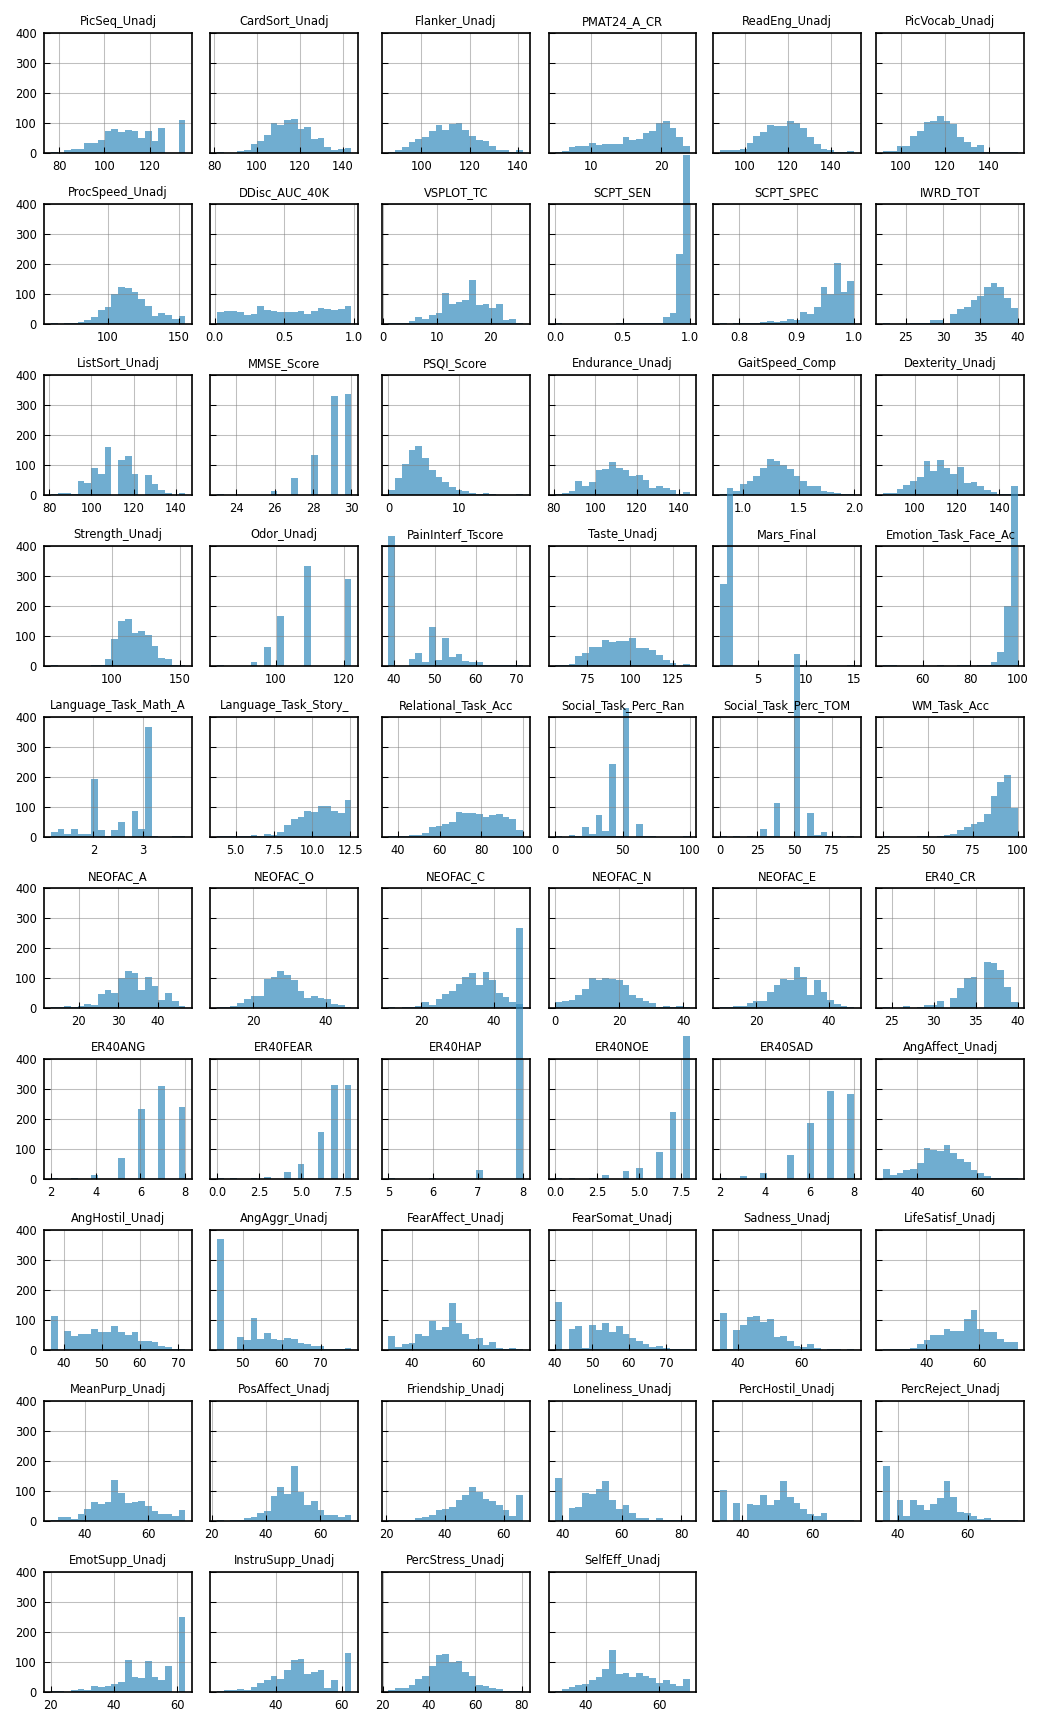

In [16]:
f = plot_behav_histograms(hcp_behav)
f.savefig(hcp_pheno_dir / f"hcp_1200_behav_histograms.{FORMAT}", bbox_inches="tight")

In [17]:
# clip to n sigma after scaling to reduce effect of outliers
clip_value_threshold = 3.0

hcp_behav_scale = hcp_behav.copy().astype(np.float64)
hcp_behav_scale.loc[:, :] = np.clip(
    scale(hcp_behav_scale.values),
    -clip_value_threshold,
    clip_value_threshold,
)
hcp_behav_scale.head(5)

,PicSeq_Unadj,CardSort_Unadj,Flanker_Unadj,PMAT24_A_CR,ReadEng_Unadj,PicVocab_Unadj,ProcSpeed_Unadj,DDisc_AUC_40K,VSPLOT_TC,SCPT_SEN,...,MeanPurp_Unadj,PosAffect_Unadj,Friendship_Unadj,Loneliness_Unadj,PercHostil_Unadj,PercReject_Unadj,EmotSupp_Unadj,InstruSupp_Unadj,PercStress_Unadj,SelfEff_Unadj
Subject,,,,,,,,,,,,,,,,,,,,,
181131,0.470076,0.088232,-0.267137,-2.435322,-2.833970,-1.666783,0.825003,-1.142457,-0.285190,-0.720718,...,-1.299936,-1.084499,1.253035,-1.589954,-1.784030,-1.439481,1.167818,0.644972,1.270140,-0.071979
245333,1.737608,-0.181166,-0.295451,0.801735,0.489478,-0.209655,0.215639,0.984194,-0.285190,0.574414,...,-0.239666,-0.256702,0.357521,0.343496,0.098973,-0.184561,-0.347506,-0.080014,0.654344,-0.854953
106824,1.737608,-0.106714,-0.074791,1.017538,0.164483,0.601523,0.365858,0.579270,0.634847,0.358127,...,-0.239666,-0.023884,0.838860,-0.148873,-0.745965,0.028539,1.167818,-0.034702,0.508792,0.368444
187547,-0.014992,0.574128,1.254053,-2.219518,0.432153,-0.433869,0.147061,-1.780726,1.324874,-0.289439,...,0.981951,0.881518,-0.101430,-1.589954,-1.784030,0.419222,-0.892587,-1.903806,-0.543659,-0.377828
211821,-0.384279,0.052965,0.451474,0.801735,-0.415580,0.306456,-0.144885,-1.368482,-0.285190,0.574414,...,-1.299936,-0.774075,-0.571574,0.643722,1.076686,0.833582,-1.906436,-0.465163,0.699129,-2.127286


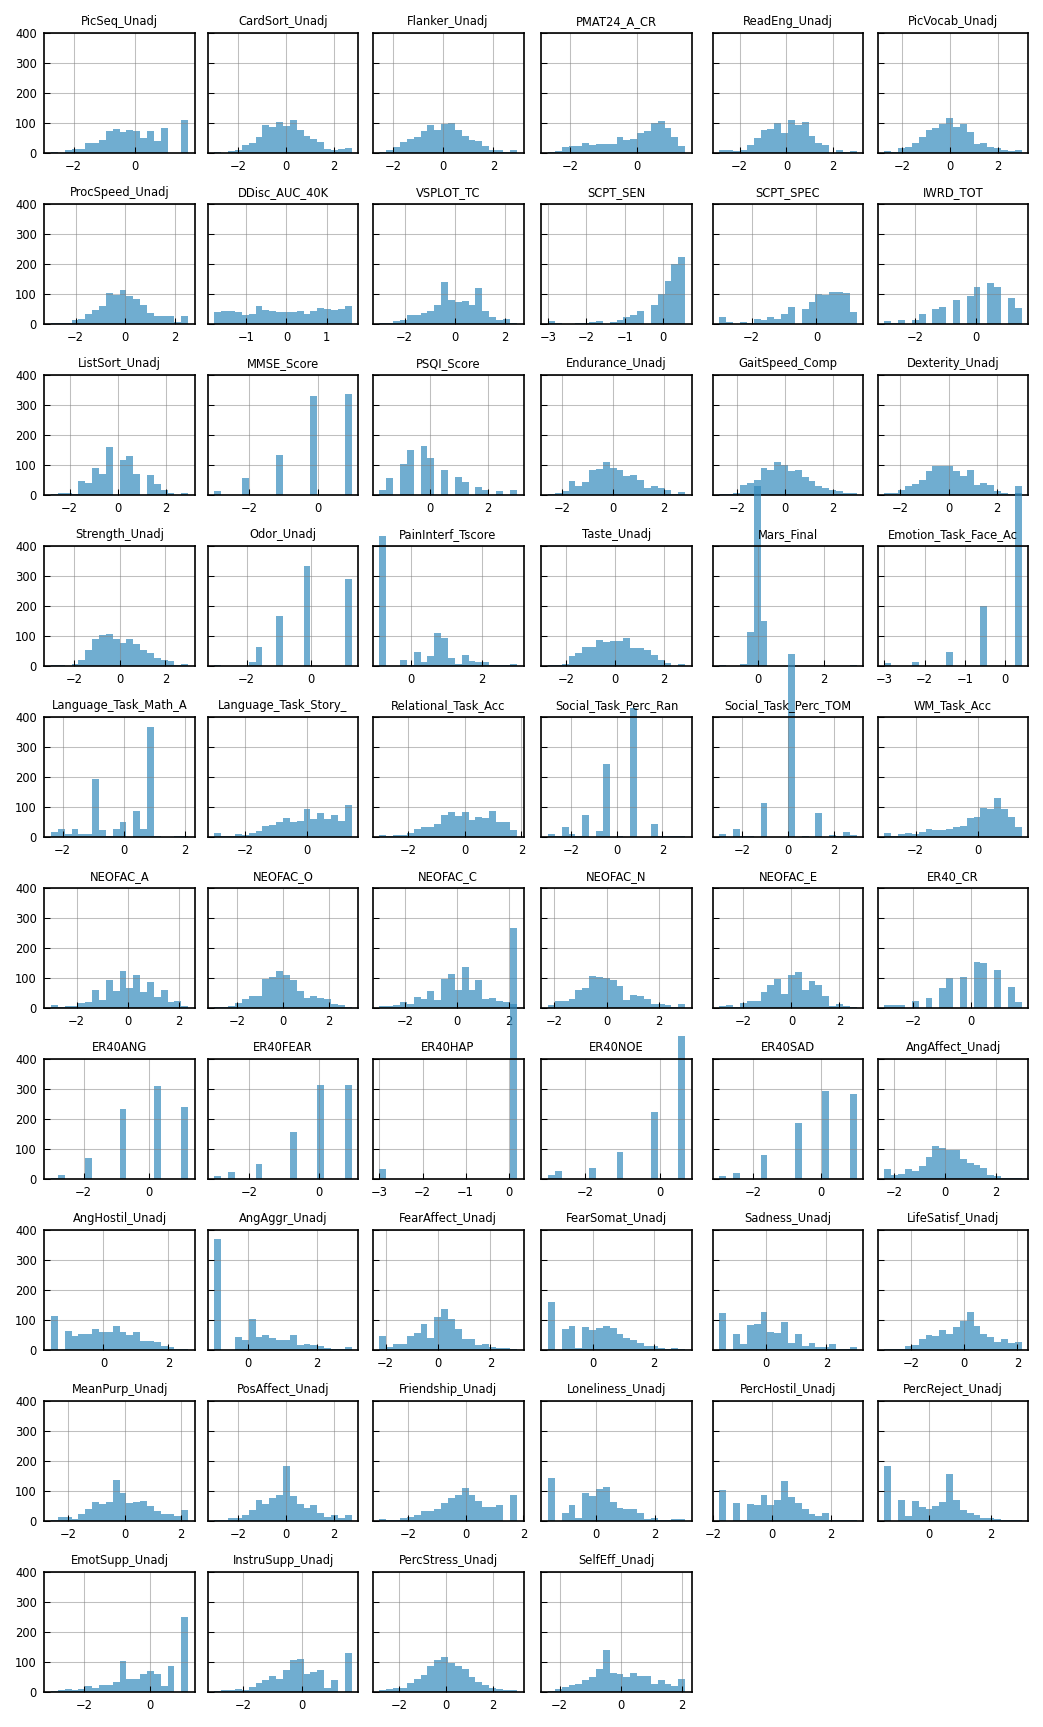

In [18]:
f = plot_behav_histograms(hcp_behav_scale)
f.savefig(
    hcp_pheno_dir / f"hcp_1200_behav_scale_histograms.{FORMAT}", bbox_inches="tight"
)

Now regress gender, age, mean FD covariates from the behavioral data.

In [19]:
def regress_covariates(data: pd.DataFrame, covariates: pd.DataFrame):
    target_names = data.columns.tolist()
    covariate_names = covariates.columns.tolist()

    merged_data = pd.concat([covariates, data], axis=1)

    resid_data = {}
    results = {}
    for target in tqdm(target_names):
        target_data = merged_data.loc[:, [target] + covariate_names]
        formula = f"{target} ~ {' + '.join(covariate_names)}"
        model = smf.ols(formula, target_data)
        result = model.fit()
        results[target] = result
        resid_data[target] = result.resid.values

    resid_data = pd.DataFrame(resid_data, index=data.index)
    return resid_data, results

In [20]:
hcp_behav_scale_clean, regression_results = regress_covariates(
    hcp_behav_scale, covariates
)

  0%|                                                                     | 0/58 [00:00<?, ?it/s]

 26%|███████████████▎                                           | 15/58 [00:00<00:00, 145.47it/s]

 53%|███████████████████████████████▌                           | 31/58 [00:00<00:00, 150.71it/s]

 81%|███████████████████████████████████████████████▊           | 47/58 [00:00<00:00, 153.03it/s]

100%|███████████████████████████████████████████████████████████| 58/58 [00:00<00:00, 152.19it/s]

In [21]:
hcp_behav_scale_clean.head(5)

,PicSeq_Unadj,CardSort_Unadj,Flanker_Unadj,PMAT24_A_CR,ReadEng_Unadj,PicVocab_Unadj,ProcSpeed_Unadj,DDisc_AUC_40K,VSPLOT_TC,SCPT_SEN,...,MeanPurp_Unadj,PosAffect_Unadj,Friendship_Unadj,Loneliness_Unadj,PercHostil_Unadj,PercReject_Unadj,EmotSupp_Unadj,InstruSupp_Unadj,PercStress_Unadj,SelfEff_Unadj
Subject,,,,,,,,,,,,,,,,,,,,,
181131,0.540833,0.492112,0.136802,-1.979735,-2.466204,-1.360382,1.129332,-0.888472,0.195048,-0.772092,...,-1.612309,-1.229857,1.199106,-1.411297,-1.679876,-1.397968,1.088413,0.618124,1.276082,-0.104676
245333,1.567257,-0.165964,-0.193425,0.785334,0.357667,-0.379425,0.232965,0.831783,-0.202262,0.519297,...,-0.186315,-0.150525,0.482595,0.275092,0.212003,-0.138027,-0.395294,-0.133059,0.589359,-0.666689
106824,1.684106,-0.524351,-0.510227,0.617179,-0.054318,0.500372,0.013868,0.441380,0.190958,0.362526,...,-0.017947,0.010081,0.784895,-0.302895,-0.862281,-0.029512,1.199150,0.044708,0.507473,0.347897
187547,-0.173676,0.612821,1.380102,-2.238507,0.261922,-0.666466,0.198651,-1.960593,1.405280,-0.364732,...,1.057643,1.021770,0.058413,-1.652961,-1.671250,0.471070,-0.917843,-1.977534,-0.603131,-0.184369
211821,-0.304215,-0.123982,0.234276,0.525121,-0.696644,0.004007,-0.227519,-1.536452,-0.626766,0.470632,...,-1.063962,-0.628975,-0.489472,0.591052,0.956423,0.802854,-1.762298,-0.490127,0.748372,-2.184197


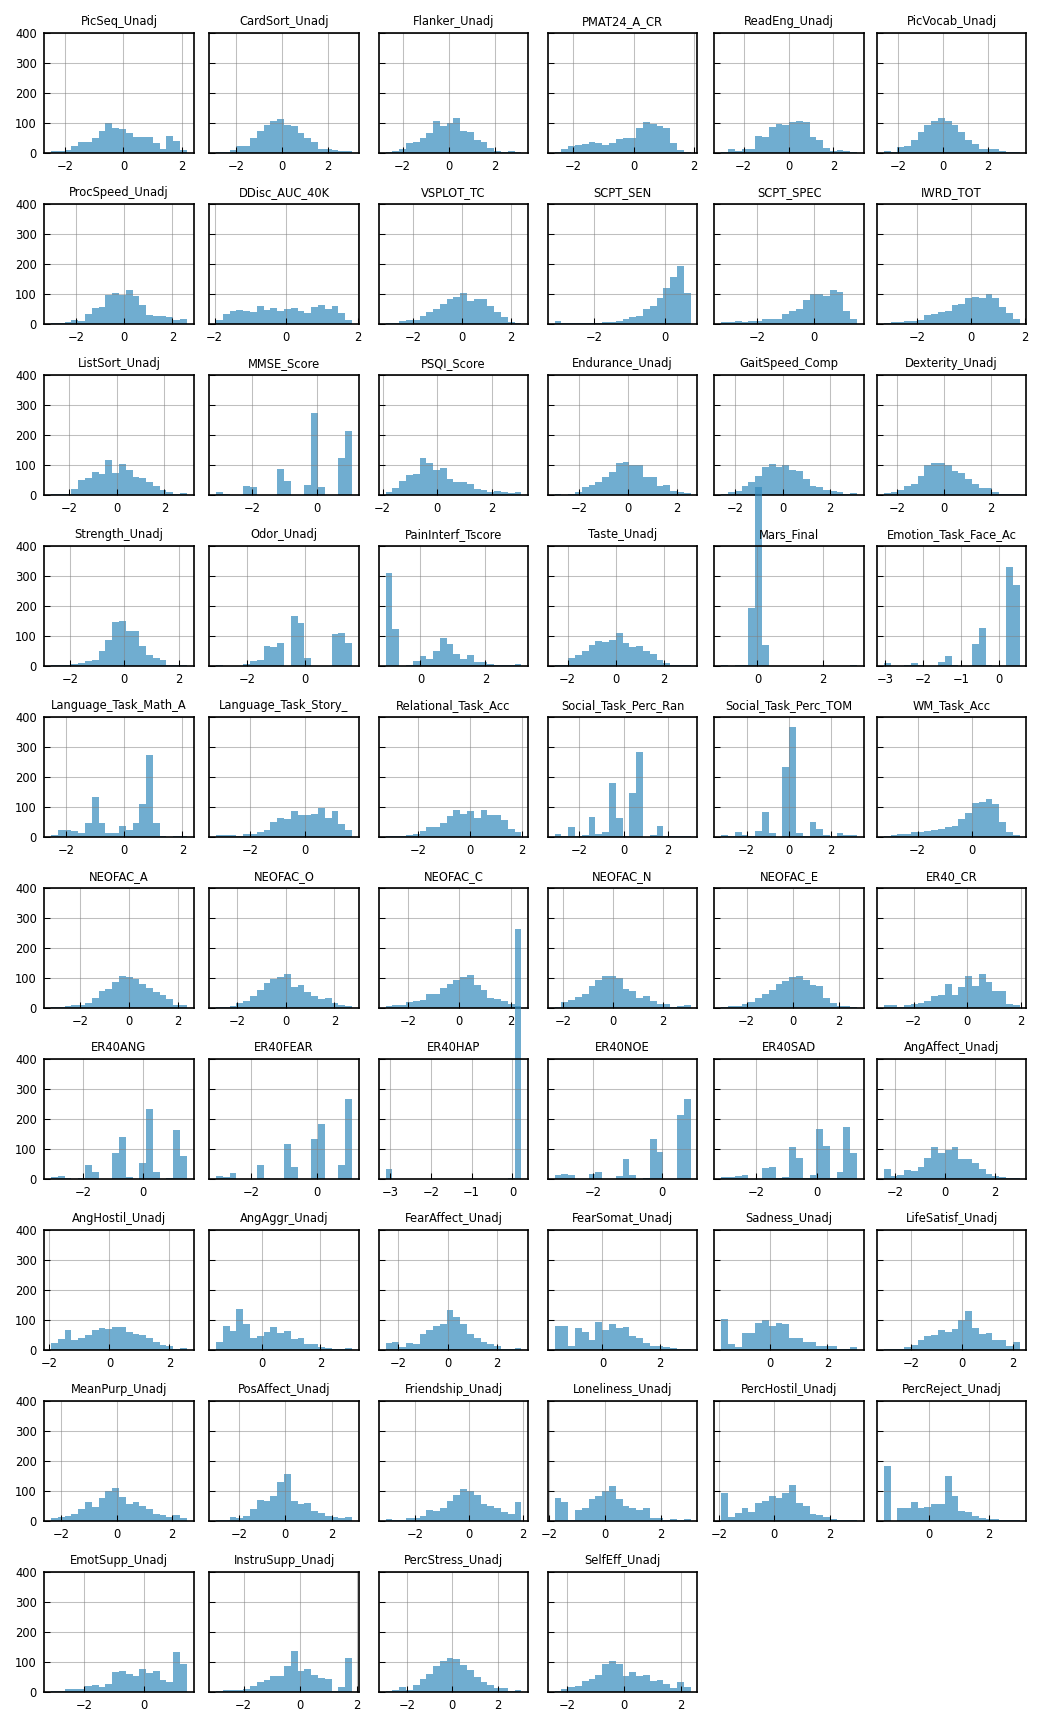

In [22]:
f = plot_behav_histograms(hcp_behav_scale_clean)
f.savefig(
    hcp_pheno_dir / f"hcp_1200_behav_scale_clean_histograms.{FORMAT}",
    bbox_inches="tight",
)

In [23]:
for target, result in regression_results.items():
    print(result.summary())

                            OLS Regression Results                            
Dep. Variable:           PicSeq_Unadj   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     8.613
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.23e-05
Time:                        16:41:35   Log-Likelihood:                -1217.4
No. Observations:                 867   AIC:                             2443.
Df Residuals:                     863   BIC:                             2462.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.0207      0.303      3.364      

                            OLS Regression Results                            
Dep. Variable:        AngAffect_Unadj   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6302
Date:                Wed, 07 May 2025   Prob (F-statistic):              0.596
Time:                        16:41:36   Log-Likelihood:                -1228.3
No. Observations:                 867   AIC:                             2465.
Df Residuals:                     863   BIC:                             2484.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.1564      0.307     -0.509      

Save scaled clean hcp 1200 behavioral data

In [24]:
hcp_behav_scale_clean.reset_index().to_parquet(
    hcp_pheno_data_dir / f"{sub_list_name}_behav_scale_clean.parquet"
)

### Factor analysis

Find the principal factors explaining the behavioral variation, following (Ooi et al., 2022) and (Kong et al., 2023).

In [25]:
embed = FactorAnalysis(n_components=4, rotation="varimax", random_state=6802)
embed.fit(hcp_behav_scale_clean)

FactorAnalysis(n_components=4, random_state=6802, rotation='varimax')

In [26]:
# flip sign so that most of the large scores are positive
component_sign = np.sign(embed.components_.sum(axis=-1))

# sort components by magnitude
component_order = np.argsort(-np.linalg.norm(embed.components_, axis=1))
component_sign = component_sign[component_order]

components = embed.components_.copy()
components = components[component_order] * component_sign[:, None]

print("Component order:", component_order)
print("Component sign:", component_sign)

Component order: [1 2 3 0]
Component sign: [ 1. -1. -1. -1.]


Save transformed component scores

In [27]:
component_scores = embed.transform(hcp_behav_scale_clean)

# Re-order and flip signs
component_scores = component_scores[:, component_order] * component_sign

component_scores = pd.DataFrame(
    component_scores,
    index=hcp_behav_scale_clean.index,
    columns=[f"comp_{ii + 1}" for ii in range(embed.n_components)],
)

component_scores.head(4)

,comp_1,comp_2,comp_3,comp_4
Subject,,,,
181131,1.559516,-1.816509,1.781506,0.004774
245333,0.243495,0.581142,0.014163,-0.035087
106824,0.045531,0.283242,0.361522,1.713816
187547,-1.290297,-0.714005,-0.617139,1.294434


In [28]:
component_scores.reset_index().to_parquet(
    hcp_pheno_data_dir / f"{sub_list_name}_component_scores.parquet"
)

Formatted table of top-k measures for each component

In [29]:
topk = 10

factor_topk_tables = []
factor_labels = ["Dissatisfaction", "Cognition", "Support", "Emotion"]

for ii, comp in enumerate(components):
    topkind = np.argsort(-np.abs(comp))[:10]
    records = []
    for jj, idx in enumerate(topkind):
        col = hcp_behav.columns[idx]
        meas = hcp_column_name_map[col]
        val = comp[idx]
        records.append({"measure": meas, "score": val})
    factor_topk_tables.append(pd.DataFrame.from_records(records))

factor_topk_table = pd.concat(factor_topk_tables, axis=1)
factor_topk_table.columns = pd.MultiIndex.from_tuples(
    [
        (f"Component {ii + 1}: {factor_labels[ii]}", col)
        for ii in range(len(components))
        for col in ["Measure", "Score"]
    ],
)

In [30]:
factor_topk_table_style = (
    factor_topk_table.style.format(precision=3)
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)
factor_topk_table_style

In [31]:
factor_topk_table_style.to_html(hcp_pheno_dir / "hcp_1200_behav_factors_topk.html")

Plot of Component scores

- Measures are sorted first by which component they score on most, then by their absolute score on that component.
- Measure values are sign flipped so that the largest component score is positive. Measures with a sign flip have a negative sign prepended on the xtick label.

In [32]:
# sort measures first by which component they contribute to most, then by their
# contribution to that component.


def argsort_components(components: np.ndarray):
    top_component_idx = np.argmax(np.abs(components), axis=0)
    indices = []
    for ii, comp in enumerate(components):
        (indices_i,) = (top_component_idx == ii).nonzero()
        order = np.argsort(-np.abs(comp[indices_i]))
        indices.append(indices_i[order])
    indices = np.concatenate(indices)
    return indices

In [33]:
component_order_indices = argsort_components(components)

In [34]:
# Flip sign of each measures based on the sign of its main component score
top_component_idx = np.argmax(np.abs(components), axis=0)
top_component = components[top_component_idx, np.arange(components.shape[1])]
feature_sign = np.sign(top_component)

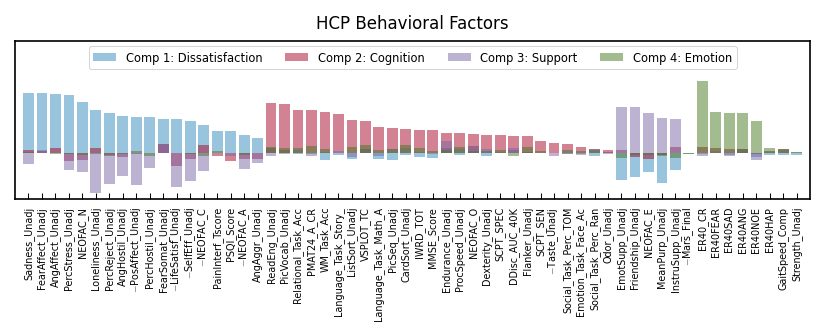

In [35]:
f, ax = plt.subplots(1, 1, figsize=(2 * PLOTW, 0.4 * PLOTW))

flip_components = components * feature_sign
bar_x = np.arange(components.shape[1])

for ii, comp in enumerate(flip_components):
    plt.bar(
        bar_x,
        comp[component_order_indices],
        alpha=0.5,
        label=f"Comp {ii + 1}: {factor_labels[ii]}",
    )

xticklabels = []
for idx in component_order_indices:
    label = hcp_behav.columns[idx][:20]
    if feature_sign[idx] < 0:
        label = f"$-${label}"
    xticklabels.append(label)

plt.xlim(-1, len(comp))
plt.ylim(-0.6, 1.5)

plt.xticks(np.arange(len(xticklabels)), xticklabels, rotation=90, fontsize="xx-small")
plt.yticks([])

plt.legend(loc="upper center", ncol=len(components), fontsize="x-small")
plt.title("HCP Behavioral Factors", fontsize="medium")

plt.grid(False)

plt.savefig(
    hcp_pheno_dir / f"hcp_1200_behav_factors_sorted.{FORMAT}", bbox_inches="tight"
)